In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#Load MNIST Dataset

print("Loading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset Shape:", X.shape)

Loading MNIST dataset...
Dataset Shape: (70000, 784)


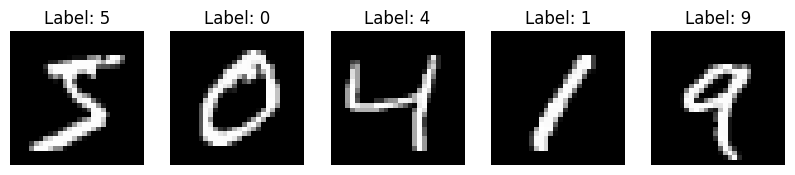

In [3]:
#Visualize Sample Images

fig, axes = plt.subplots(1, 5, figsize=(10,4))

for i, ax in enumerate(axes):
    ax.imshow(X.iloc[i].values.reshape(28,28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.show()

In [5]:
#Normalize Data

X = X / 255.0

In [6]:
#Split Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (56000, 784)
Testing samples: (14000, 784)


In [7]:
#Build Neural Network Model

model = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation='relu',
    solver='adam',
    max_iter=20,
    random_state=42
)

In [8]:
#Train the Model

print("Training the model...")

model.fit(X_train, y_train)

print("Training completed")

Training the model...
Training completed


C:\Users\Malli Mounika\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [9]:
#Model Evaluation

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9305714285714286


In [10]:
#Classification Report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1343
           1       0.95      0.97      0.96      1600
           2       0.94      0.92      0.93      1380
           3       0.91      0.92      0.91      1433
           4       0.92      0.93      0.92      1295
           5       0.91      0.90      0.90      1273
           6       0.95      0.95      0.95      1396
           7       0.93      0.95      0.94      1503
           8       0.92      0.88      0.90      1357
           9       0.91      0.91      0.91      1420

    accuracy                           0.93     14000
   macro avg       0.93      0.93      0.93     14000
weighted avg       0.93      0.93      0.93     14000



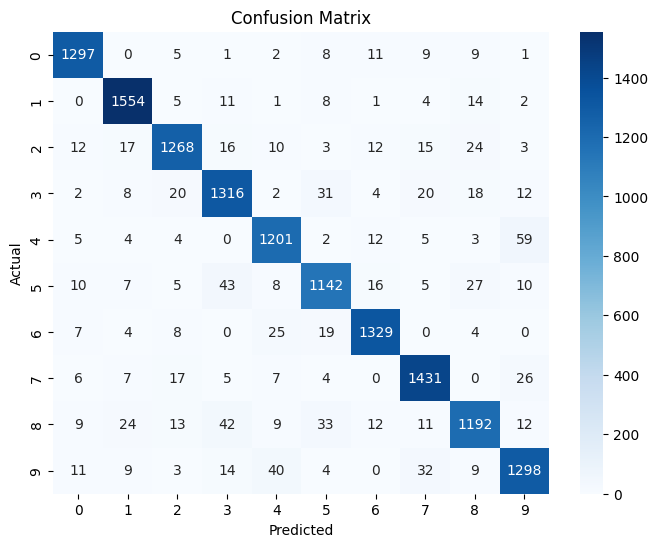

In [11]:
#Confusion Matrix

import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

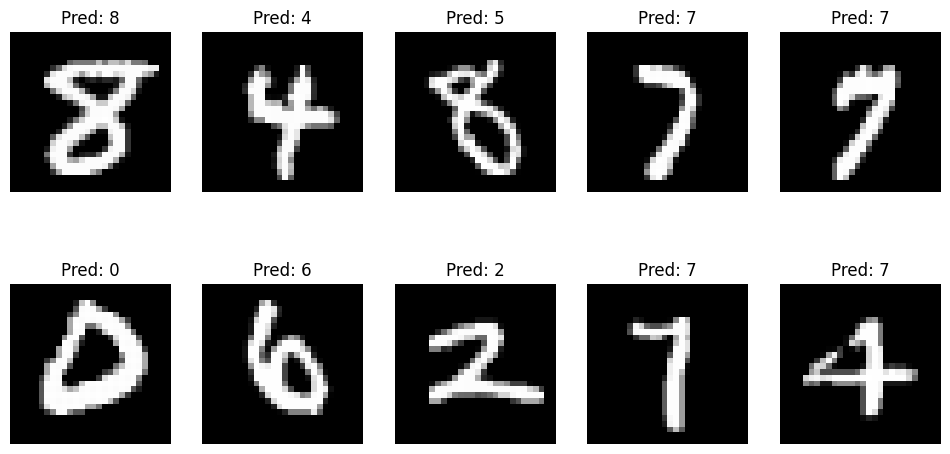

In [12]:
#Visualize Predictions

fig, axes = plt.subplots(2,5, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test.iloc[i].values.reshape(28,28), cmap='gray')
    ax.set_title(f"Pred: {y_pred[i]}")
    ax.axis('off')

plt.show()

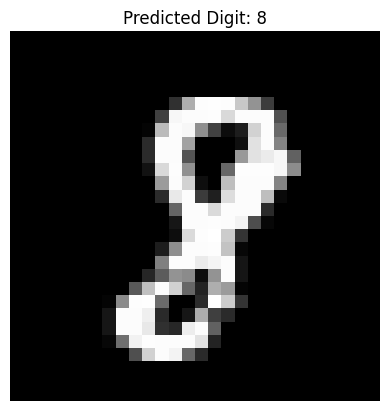

In [14]:
# Test with Random Image

index = np.random.randint(0, len(X_test))

# Get image properly
image = X_test.iloc[index].values.reshape(28,28)

# Correct prediction format (DataFrame row)
prediction = model.predict(X_test.iloc[[index]])

plt.imshow(image, cmap='gray')
plt.title(f"Predicted Digit: {prediction[0]}")
plt.axis('off')
plt.show()